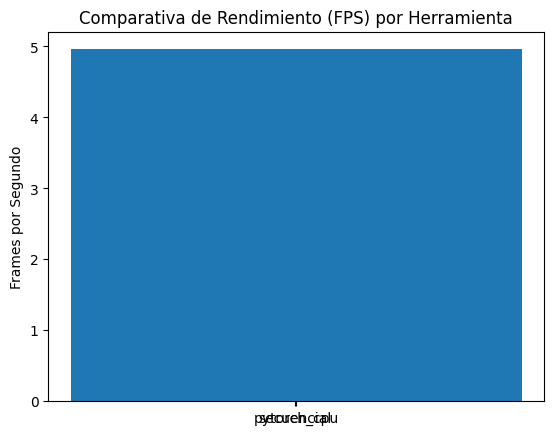

,Metodo,T_Perdido_Disco(s),T_Transf_IN(s),T_Computo_1(s),T_Computo_2(s),T_Computo_Total(s),T_Transf_OUT(s),T_Total_Global(s),Speed-Up,Performance(%)
0,secuencial,0.2234,0.0,484.4454,0.0,484.4454,0.0,484.6689,1.00,100.0
1,pytorch_cpu,0.2505,0.0,97.5028,0.0,97.5028,0.0,97.7533,4.96,495.8


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definimos la ruta (asumiendo que graficos.ipynb está en la raíz del proyecto)
ruta_csv = 'static/res/reporte_estadistico.csv'

try:
    # 2. skiprows=3 ignora la info de hardware/software y usa la fila 4 como columnas
    df = pd.read_csv(ruta_csv, skiprows=3)

# Asumiendo que 'df' es el dataframe que cargamos antes
    plt.figure(figsize=(10, 6))

    # Creamos el gráfico de barras
    bars = plt.bar(df['Metodo'], df['Speed-Up'], color=['#3498db', '#e74c3c', '#2ecc71'])

    # Etiquetas y títulos
    plt.title('Comparativa de Aceleración (Speed-Up) por Método', fontsize=14)
    plt.xlabel('Herramienta / Pipeline', fontsize=12)
    plt.ylabel('Speed-Up (Veces más rápido que Secuencial)', fontsize=12)
    plt.axhline(y=1, color='gray', linestyle='--', label='Baseline (Secuencial)')

    # Añadimos los valores encima de cada barra para que sea profesional
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval}x', ha='center', va='bottom')

    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

except FileNotFoundError:
    print(f"❌ No se encontró el archivo en: {ruta_csv}")
    print("Asegúrate de haber ejecutado benchmark.py primero.")



In [ ]:
import pandas as pd

# 1. Definimos la ruta (asumiendo que graficos.ipynb está en la raíz del proyecto)
ruta_csv = 'static/res/reporte_estadistico.csv'

try:
    # 2. skiprows=3 ignora la info de hardware/software y usa la fila 4 como columnas
    df = pd.read_csv(ruta_csv, skiprows=3)

    # 3. Limpieza de datos (Convertimos texto a números reales para poder graficar)
    if 'Speed-Up' in df.columns:
        df['Speed-Up'] = df['Speed-Up'].astype(str).str.replace('x', '').astype(float)
        
    if 'Performance(%)' in df.columns:
        df['Performance(%)'] = df['Performance(%)'].astype(str).str.replace('%', '').astype(float)

    # Mostrar la tabla bonita en el notebook
    display(df)

except FileNotFoundError:
    print(f"❌ No se encontró el archivo en: {ruta_csv}")
    print("Asegúrate de haber ejecutado benchmark.py primero.")